# ioNERDSS OVITO Visualization Tutorial

> **Deprecated:** `visualize_trajectory_ovito` will be removed in a future release. See [`ionerdss_tutorial_trajectory_movie.ipynb`](ionerdss_tutorial_trajectory_movie.ipynb) for `render_trajectory_movie`, which needs no OVITO and draws the simulation box, the time and one color per molecule type.

This tutorial demonstrates how to visualize NERDSS trajectory outputs using [OVITO](https://www.ovito.org/) and save them as GIF animations.

> You may directly open the `trajectory.xyz` file output by NERDSS using OVITO for better customization with the OVITO user interface.

## Installation Requirement 
To use this visualization tool, you **must install `ioNERDSS` with the `ovito_rendering` optional dependency** because OVITO, ImageIO, and Pillow are heavy graphics-rendering libraries omitted from the base installation.

Run the following command in your terminal or Jupyter environment's command prompt:
```bash
pip install "ioNERDSS[ovito_rendering]"
```
*(If you are installing from source, you can run `pip install -e ".[ovito_rendering]".)*


In [1]:
# Import the library
import ionerdss
import logging

# Set up logging so we can see progress and any missing dependency warnings
logging.basicConfig(level=logging.INFO)


## Step 1: Simulate your System (or use an existing workspace)

For this tutorial, let's assume you've already run a simulation and have an output folder (for example, `6bno_dir/nerdss_files`, which `ionerdss_tutorial_6bno.ipynb` creates next to this notebook). 

When NERDSS completes a simulation successfully, it generates a trajectory file that contains all atom/bead positions over time.
This file is typically located at:
`<pdb_id>_dir/nerdss_files/DATA/trajectory.xyz`


In [2]:
# Define where your NERDSS XYZ trajectory lives.
# For example, if you ran the 6bno tutorial, it might be:
trajectory_file_path = "./6bno_dir/nerdss_files/DATA/trajectory.xyz"
print(f"xyz file : {trajectory_file_path}")

xyz file : ./6bno_dir/nerdss_files/DATA/trajectory.xyz


## Step 2: Render into a GIF Animation

Next, we simply use the `visualize_trajectory_ovito` function! It will securely load your `.xyz` trajectory, configure a 3D perspective viewport, render each frame natively through OVITO's rendering engine, and compile it into a seamless GIF.


In [3]:
try:
    print(f"Beginning rendering for: {trajectory_file_path}")
    ionerdss.visualize_trajectory_ovito(
        trajectory_path=trajectory_file_path,
        save_gif=True, 
        gif_name="./6bno_dir/6bno_trajectory.gif", # The requested name of your output file
        fps=2, # The speed of your animation (Frames per second)
        show_simulation_box=False # Set to True to display the simulation cell bounding box
    )
    
except Exception as e:
    print(f"Error occurred during generation: {e}")


/var/folders/66/f7711m0d487470_bqdkf4jn80000gn/T/ipykernel_71413/3992179298.py:3: DeprecationWarning: visualize_trajectory_ovito is deprecated and will be removed in a future release. Use ionerdss.render_trajectory_movie(<NERDSS run directory>, 'trajectory.gif'), which needs no OVITO and draws the simulation box, the time and one color per molecule type.
  ionerdss.visualize_trajectory_ovito(
INFO:ionerdss.ovito_visualizer:Rendering ./6bno_dir/nerdss_files/DATA/trajectory.xyz with OVITO in a separate process...


Beginning rendering for: ./6bno_dir/nerdss_files/DATA/trajectory.xyz


INFO:ionerdss.ovito_visualizer:OVITO version: 3.15.5


INFO:ionerdss.ovito_visualizer:Using OVITO renderer: OSPRayRenderer


INFO:ionerdss.ovito_visualizer:Rendering frame 1/11


...

INFO:ionerdss.ovito_visualizer:Rendering frame 9/11


INFO:ionerdss.ovito_visualizer:Rendering frame 10/11


INFO:ionerdss.ovito_visualizer:Rendering frame 11/11


INFO:ionerdss.ovito_visualizer:Compiling GIF at 2 fps...


INFO:ionerdss.ovito_visualizer:Successfully saved animation to 6bno_dir/6bno_trajectory.gif


## Step 3: View the Output

The process might take a few minutes depending on the length of your simulation (number of frames).
Once done, simply open `6bno_trajectory.gif` in any image viewer or web browser.

If you are inside a Jupyter Notebook environment, you can display it using `IPython`:


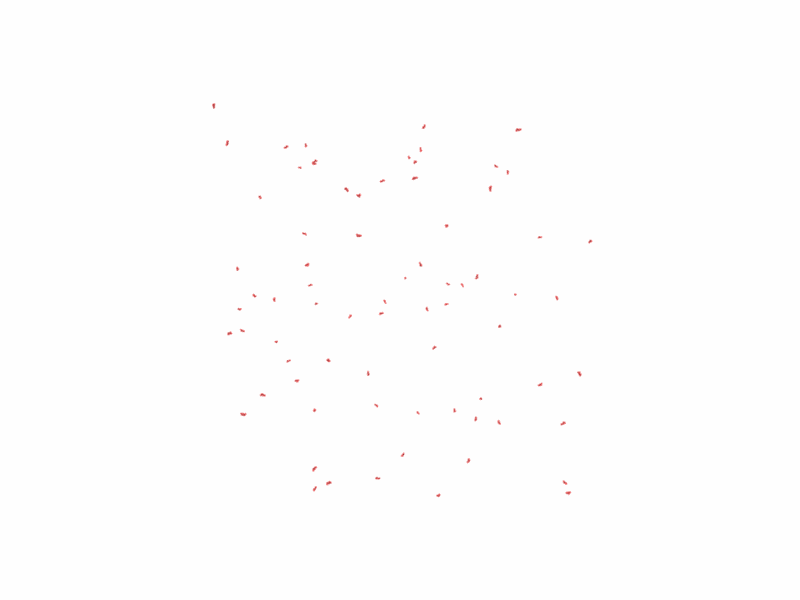

In [4]:
from IPython.display import Image

Image(filename="./6bno_dir/6bno_trajectory.gif")

You can also open the desktop Ovito application and load in the trajectory.xyz file, or the PDB/*pdb files for interactive viewing.